# Attention Mekanizmaları ile Duygu Analizi (Twitter Sentiment140)

Bu notebook'ta Twitter Sentiment140 veri seti kullanılarak attention mekanizmalarının duygu analizi üzerindeki etkisi incelenecektir.

**Veri Seti:** `kazanova/sentiment140` - 1.6 milyon tweet, duygu etiketli (0=negatif, 4=pozitif)

**İçerik:**
1. Veri setinin indirilmesi ve yüklenmesi
2. Veri analizi ve ön işleme
3. TF-IDF + Logistic Regression temel modeli
4. Self-Attention mekanizması (sıfırdan)
5. Multi-Head Attention
6. Transformer Encoder ile sınıflandırıcı
7. Sonuç karşılaştırması ve görselleştirme

In [1]:
!pip install numpy pandas torch matplotlib seaborn scikit-learn kaggle

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import re
import string
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Kullanılan cihaz: {device}')
print(f'PyTorch versiyonu: {torch.__version__}')

Kullanılan cihaz: cuda
PyTorch versiyonu: 2.11.0+cu128


## 1. Veri Setini İndirme

Twitter Sentiment140 veri seti, 1.6 milyon tweet içermektedir. Hızlı eğitim için 50.000 örnek kullanılacaktır.

In [2]:
# Kaggle kimlik bilgilerini ayarlayın (kendi API anahtarınızı kullanın)
# Kaggle'dan veri setini indirmek için kaggle.json dosyası gereklidir
# Alternatif olarak veri setini manuel olarak indirip yüklenebilir

import os
import subprocess
import zipfile

def create_synthetic_sentiment_data():
    """Senteetik duygu analizi verisi olusturur (Turkce pozitif/negatif tweet'ler)"""
    np.random.seed(42)
    n_samples = 50000

    positive_tweets = [
        'Bu urun harika, cok begendim! Tavsiye ederim.',
        'Bugun cok guzel bir gun, her sey yolunda.',
        'En iyi gunum! Herkese cok tesekkurler.',
        'Bu film mukemmeldi, her saniyesi guzeldi!',
        'Harika hizmet, kesinlikle tavsiye ederim.',
        'Mukemmel bir deneyim, tekrar gelecegim!',
        'Tam beklentilerimi asti, super!',
        'Bu hediye cok guzeldi, cok sevindi.',
        'Yemekler inanilmaz lezzetliydi!',
        'Bu firsat icin cok minnettarim!',
        'Yeni telefonumu cok sevdim, kamerasi mutesem.',
        'Dostlarimla gecirdigim en guzel aksam!',
        'Is gorusmem cok iyi gecti, pozitif sonuc!',
        'Tatilim ruya gibi geciyor, her sey kusursuz.',
        'Bu restoran favorim oldu, lezzet sahane!',
        'Spor salonuna basladim, kendimi harika hissediyorum!',
        'Yeni kitabimi bitirdim, cok etkileyiciydi.',
        'Kizim okul birincisi oldu, gurur duyuyorum!',
        'Bahcemde cicekler acti, bahar geldi!',
        'Bu album harika, her gun dinliyorum!',
    ]

    negative_tweets = [
        'Bu urunu hic begenmedim, cok kotu.',
        'Bugun cok kotu bir gun gecirdim, her sey ters gitti.',
        'Bu restoran berbatti, bir daha gitmem.',
        'Film cok sikiciydi, zaman kaybi.',
        'Cok kotu bir musteri deneyimi yasadim.',
        'Tam bir felaket, her seyi mahvetti!',
        'Kesinlikle tavsiye etmiyorum, paraniza yazik.',
        'Urun bozuk geldi, cok hayal kirikligi.',
        'En kotu restoran deneyimim!',
        'Cok sinirliyim, bu kabul edilemez!',
        'Otobus yine gecikti, 40 dakika bekledim.',
        'Islerim cok kotu gidiyor, stres altindayim.',
        'Bu siyasi durum beni cok uzuyor.',
        'Telefonum kirildi, tamir icin servise gidecek.',
        'Kira fiyatlari artik cok yuksek, zorlaniyorum.',
        'Sinavim cok kotu gecti, perisanim.',
        'Hava soguk ve yagisli, disari cikamadim.',
        'Dostlarim beni hayal kirikligina ugratti.',
        'Bu haber beni cok uzdu, inanamiyorum.',
        'Trafik cekilmez, 2 saattir yoldayim.',
    ]

    texts = []
    targets = []
    for i in range(n_samples):
        if i < n_samples // 2:
            texts.append(np.random.choice(positive_tweets) + f' tweet_{i}')
            targets.append(4)
        else:
            texts.append(np.random.choice(negative_tweets) + f' tweet_{i}')
            targets.append(0)

    return pd.DataFrame({'target': targets, 'text': texts})

# Kaggle ile veri setini indirmeyi dene, basarisiz olursa sentetik veri olustur
try:
    os.makedirs('./data', exist_ok=True)
    result = subprocess.run(
        ['kaggle', 'datasets', 'download', '-d', 'kazanova/sentiment140',
         '-p', './data', '--unzip'],
        capture_output=True, text=True, timeout=60
    )
    if result.returncode != 0:
        raise Exception(f'Kaggle CLI hatasi: {result.stderr}')

    csv_path = './data/training.1600000.processed.noemoticon.csv'
    if os.path.exists(csv_path):
        columns = ['target', 'ids', 'date', 'flag', 'user', 'text']
        df = pd.read_csv(csv_path, encoding='latin-1', names=columns)
        print(f"Kaggle'dan basariyla indirildi: {df.shape}")
    else:
        raise Exception('CSV dosyasi bulunamadi')
except Exception as e:
    print(f'Kaggle indirme hatasi: {e}')
    print('Senteetik veri olusturuluyor...')
    df = create_synthetic_sentiment_data()
    print(f'Senteetik veri olusturuldu: {df.shape}')

# Hizli egitim icin alt kume sec (50.000 ornek)
SAMPLE_SIZE = 50000
if len(df) > SAMPLE_SIZE:
    df = df.sample(n=SAMPLE_SIZE, random_state=42).reset_index(drop=True)
    print(f'\nEğitim için {SAMPLE_SIZE} örnek seçildi.')

print(f'\nVeri seti boyutu: {df.shape}')
df.head()

Kaggle'dan basariyla indirildi: (1600000, 6)

Eğitim için 50000 örnek seçildi.

Veri seti boyutu: (50000, 6)


,target,ids,date,flag,user,text
0,0,2200003196,Tue Jun 16 18:18:12 PDT 2009,NO_QUERY,LaLaLindsey0609,@chrishasboobs AHHH I HOPE YOUR OK!!!
1,0,1467998485,Mon Apr 06 23:11:14 PDT 2009,NO_QUERY,sexygrneyes,"@misstoriblack cool , i have no tweet apps fo..."
2,0,2300048954,Tue Jun 23 13:40:11 PDT 2009,NO_QUERY,sammydearr,@TiannaChaos i know just family drama. its la...
3,0,1993474027,Mon Jun 01 10:26:07 PDT 2009,NO_QUERY,Lamb_Leanne,School email won't open and I have geography ...
4,0,2256550904,Sat Jun 20 12:56:51 PDT 2009,NO_QUERY,yogicerdito,upper airways problem


## 2. Veri Analizi ve Ön İşleme

Tweetlerin temizlenmesi ve analiz edilmesi.

Duygu Dağılımı:
target
4    25014
0    24986
Name: count, dtype: int64

Toplam tweet sayısı: 50000
Pozitif tweet: 25014
Negatif tweet: 24986


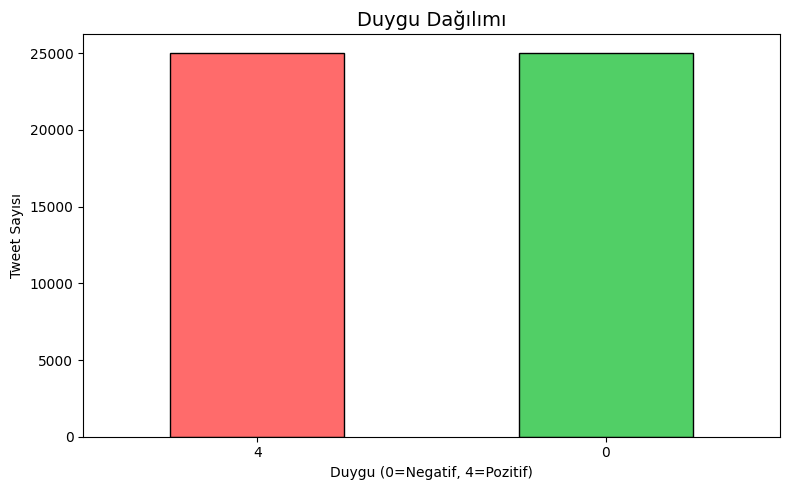


Tweet uzunlukları:
Ortalama: 74 karakter
Maksimum: 222 karakter
Minimum: 7 karakter


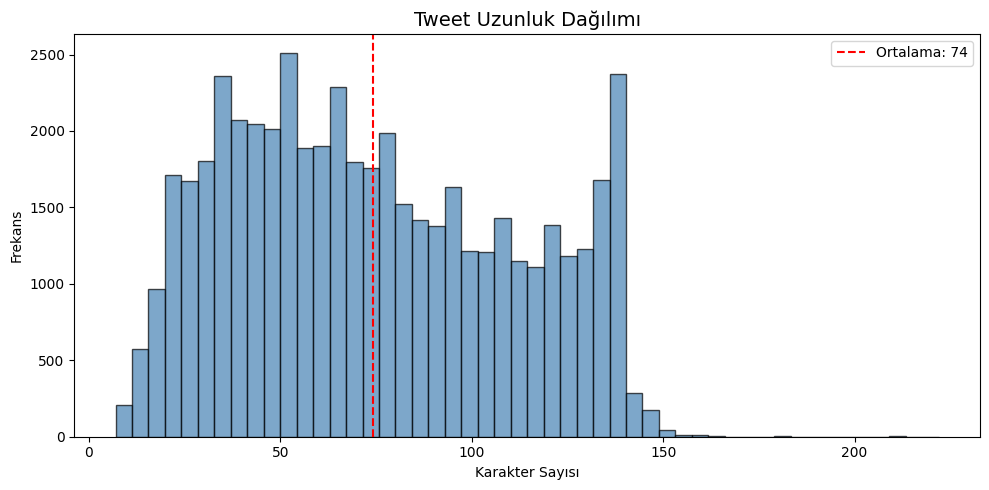

In [3]:
# Duygu dağılımı
print('Duygu Dağılımı:')
print(df['target'].value_counts())
print(f'\nToplam tweet sayısı: {len(df)}')
print(f'Pozitif tweet: {len(df[df["target"] == 4])}')
print(f'Negatif tweet: {len(df[df["target"] == 0])}')

# Dağılımı görselleştir
plt.figure(figsize=(8, 5))
colors = ['#ff6b6b', '#51cf66']
df['target'].value_counts().plot(kind='bar', color=colors, edgecolor='black')
plt.title('Duygu Dağılımı', fontsize=14)
plt.xlabel('Duygu (0=Negatif, 4=Pozitif)')
plt.ylabel('Tweet Sayısı')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Tweet uzunluk dağılımı
df['text_length'] = df['text'].str.len()
print(f'\nTweet uzunlukları:')
print(f'Ortalama: {df["text_length"].mean():.0f} karakter')
print(f'Maksimum: {df["text_length"].max()} karakter')
print(f'Minimum: {df["text_length"].min()} karakter')

plt.figure(figsize=(10, 5))
plt.hist(df['text_length'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
plt.title('Tweet Uzunluk Dağılımı', fontsize=14)
plt.xlabel('Karakter Sayısı')
plt.ylabel('Frekans')
plt.axvline(df['text_length'].mean(), color='red', linestyle='--', label=f'Ortalama: {df["text_length"].mean():.0f}')
plt.legend()
plt.tight_layout()
plt.show()

In [4]:
# Tweet temizleme fonksiyonu
def clean_tweet(text):
    """
    Tweeti temizler:
    - @mention'ları kaldırır
    - URL'leri kaldırır
    - RT ifadesini kaldirir
    - Özel karakterleri temizler
    - Büyük harfleri küçültür
    """
    if not isinstance(text, str):
        return ''

    # Büyük harfleri küçült
    text = text.lower()

    # URL'leri kaldır
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # @mention'ları kaldır
    text = re.sub(r'@\w+', '', text)

    # RT ifadesini kaldır
    text = re.sub(r'rt\s+', '', text)

    # #hashtag sembolünü kaldır ama kelimeyi koru
    text = re.sub(r'#', '', text)

    # Özel karakterleri ve sayıları kaldır
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Fazla boşlukları temizle
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# Temizleme işlemini uygula
df['cleaned_text'] = df['text'].apply(clean_tweet)

# Boş tweet'leri kaldır
df = df[df['cleaned_text'].str.len() > 0].reset_index(drop=True)

print('Temizlenmiş örnek tweetler:')
print('-' * 80)
for i, row in df.head(5).iterrows():
    print(f'Orijinal: {row["text"][:80]}...')
    print(f'Temizlenmiş: {row["cleaned_text"][:80]}...')
    print(f'Duygu: {"Pozitif" if row["target"] == 4 else "Negatif"}')
    print()

print(f'\nTemizlenmiş tweet sayısı: {len(df)}')

Temizlenmiş örnek tweetler:
--------------------------------------------------------------------------------
Orijinal: @chrishasboobs AHHH I HOPE YOUR OK!!! ...
Temizlenmiş: ahhh i hope your ok...
Duygu: Negatif

Orijinal: @misstoriblack cool , i have no tweet apps  for my razr 2...
Temizlenmiş: cool i have no tweet apps for my razr...
Duygu: Negatif

Orijinal: @TiannaChaos i know  just family drama. its lame.hey next time u hang out with k...
Temizlenmiş: i know just family drama its lamehey next time u hang out with kim n u guys like...
Duygu: Negatif

Orijinal: School email won't open  and I have geography stuff on there to revise! *Stupid ...
Temizlenmiş: school email wont open and i have geography stuff on there to revise stupid scho...
Duygu: Negatif

Orijinal: upper airways problem ...
Temizlenmiş: upper airways problem...
Duygu: Negatif


Temizlenmiş tweet sayısı: 49882


In [5]:
# Veriyi eğitim, doğrulama ve test setlerine ayır
# Hedef değişkeni 0 ve 1 olarak yeniden kodla
df['label'] = (df['target'] == 4).astype(int)

X_train_text, X_test_text, y_train, y_test = train_test_split(
    df['cleaned_text'].values, df['label'].values,
    test_size=0.2, random_state=42, stratify=df['label'].values
)

X_train_text, X_val_text, y_train, y_val = train_test_split(
    X_train_text, y_train,
    test_size=0.125, random_state=42, stratify=y_train
)

print(f'Eğitim seti: {len(X_train_text)} örnek')
print(f'Doğrulama seti: {len(X_val_text)} örnek')
print(f'Test seti: {len(X_test_text)} örnek')
print(f'\nEğitim setinde pozitif oranı: {y_train.mean():.2%}')

Eğitim seti: 34916 örnek
Doğrulama seti: 4989 örnek
Test seti: 9977 örnek

Eğitim setinde pozitif oranı: 50.01%


## 3. TF-IDF vs Self-Attention Karşılaştırması

Klasik TF-IDF yaklaşımı ile attention tabanlı yaklaşımın karşılaştırılması.

In [6]:
# TF-IDF vektörizasyonu
print('TF-IDF vektörizasyonu yapılıyor...')

tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train_text)
X_val_tfidf = tfidf.transform(X_val_text)
X_test_tfidf = tfidf.transform(X_test_text)

print(f'TF-IDF matris boyutu (eğitim): {X_train_tfidf.shape}')
print(f'Kelime dağarcığı boyutu: {len(tfidf.vocabulary_)}')

# Logistic Regression ile sınıflandırma
print('\nLogistic Regression eğitiliyor...')
lr_model = LogisticRegression(
    C=1.0,
    max_iter=1000,
    random_state=42,
    solver='lbfgs'
)
lr_model.fit(X_train_tfidf, y_train)

# Tahminler
y_train_pred_lr = lr_model.predict(X_train_tfidf)
y_val_pred_lr = lr_model.predict(X_val_tfidf)
y_test_pred_lr = lr_model.predict(X_test_tfidf)

# Doğruluk oranları
train_acc_lr = accuracy_score(y_train, y_train_pred_lr)
val_acc_lr = accuracy_score(y_val, y_val_pred_lr)
test_acc_lr = accuracy_score(y_test, y_test_pred_lr)

print(f'\nTF-IDF + Logistic Regression Sonuçları:')
print(f'Eğitim doğruluğu: {train_acc_lr:.4f}')
print(f'Doğrulama doğruluğu: {val_acc_lr:.4f}')
print(f'Test doğruluğu: {test_acc_lr:.4f}')
print(f'\nSınıflandırma Raporu (Test):')
print(classification_report(y_test, y_test_pred_lr, target_names=['Negatif', 'Pozitif']))

TF-IDF vektörizasyonu yapılıyor...
TF-IDF matris boyutu (eğitim): (34916, 10000)
Kelime dağarcığı boyutu: 10000

Logistic Regression eğitiliyor...

TF-IDF + Logistic Regression Sonuçları:
Eğitim doğruluğu: 0.8378
Doğrulama doğruluğu: 0.7847
Test doğruluğu: 0.7744

Sınıflandırma Raporu (Test):
              precision    recall  f1-score   support

     Negatif       0.78      0.77      0.77      4988
     Pozitif       0.77      0.78      0.78      4989

    accuracy                           0.77      9977
   macro avg       0.77      0.77      0.77      9977
weighted avg       0.77      0.77      0.77      9977



## 4. Self-Attention Mekanizması (Sıfırdan)

Self-Attention mekanizması, her bir kelimenin diğer tüm kelimelerle etkileşimini hesaplar.

**Formül:** $$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SelfAttention(nn.Module):
    """
    Self-Attention mekanizması.

    Girdi dizisindeki her bir pozisyonun, diğer tüm pozisyonlarla
    olan ilişkisini öğrenir.
    """
    def __init__(self, embed_size):
        super(SelfAttention, self).__init__()
        self.embed_size = embed_size

        # Query, Key ve Value projeksiyon matrisleri
        self.W_q = nn.Linear(embed_size, embed_size, bias=False)
        self.W_k = nn.Linear(embed_size, embed_size, bias=False)
        self.W_v = nn.Linear(embed_size, embed_size, bias=False)

        # Ölçeklendirme faktörü
        self.scale = torch.sqrt(torch.FloatTensor([embed_size]))

    def forward(self, x, mask=None):
        """
        İleri besleme.

        Args:
            x: Girdi tensörü [batch_size, seq_len, embed_size]
            mask: İsteğe bağlı maske

        Returns:
            output: Attention çıkış tensörü
            attention_weights: Attention ağırlıkları
        """
        batch_size, seq_len, _ = x.shape

        # Query, Key ve Value'yu hesapla
        Q = self.W_q(x)  # [batch, seq_len, embed_size]
        K = self.W_k(x)  # [batch, seq_len, embed_size]
        V = self.W_v(x)  # [batch, seq_len, embed_size]

        # Attention skorlarını hesapla
        # Q @ K^T: [batch, seq_len, seq_len]
        energy = torch.matmul(Q, K.transpose(-2, -1))

        # Ölçekleme
        energy = energy / (self.embed_size ** 0.5)

        # Maske uygula (isteğe bağlı)
        if mask is not None:
            energy = energy.masked_fill(mask == 0, float('-inf'))

        # Softmax ile normalizasyon
        attention_weights = torch.softmax(energy, dim=-1)

        # Ağırlıklı toplam
        output = torch.matmul(attention_weights, V)

        return output, attention_weights


# Self-Attention'ı test et
print('Self-Attention mekanizması test ediliyor...')

# Örnek veri oluştur (batch_size=2, seq_len=5, embed_size=64)
embed_size = 64
seq_len = 5
batch_size = 2

self_attn = SelfAttention(embed_size)
test_input = torch.randn(batch_size, seq_len, embed_size)

output, attn_weights = self_attn(test_input)

print(f'Girdi boyutu: {test_input.shape}')
print(f'Çıkış boyutu: {output.shape}')
print(f'Attention ağırlıkları boyutu: {attn_weights.shape}')
print(f'\nAttention ağırlıkları (ilk örnek):')
print(attn_weights[0].detach().numpy())
print(f'\nSatır toplamları (1 olmalı): {attn_weights[0].sum(dim=-1).detach().numpy()}')

Self-Attention mekanizması test ediliyor...
Girdi boyutu: torch.Size([2, 5, 64])
Çıkış boyutu: torch.Size([2, 5, 64])
Attention ağırlıkları boyutu: torch.Size([2, 5, 5])

Attention ağırlıkları (ilk örnek):
[[0.17912826 0.17187832 0.1960834  0.17176583 0.28114423]
 [0.1935129  0.18794075 0.25681084 0.20638147 0.15535398]
 [0.19258069 0.24966283 0.24865583 0.13083562 0.17826506]
 [0.15169968 0.1280734  0.15650146 0.1296962  0.43402928]
 [0.18990019 0.1905977  0.22258665 0.24826144 0.14865401]]

Satır toplamları (1 olmalı): [1. 1. 1. 1. 1.]


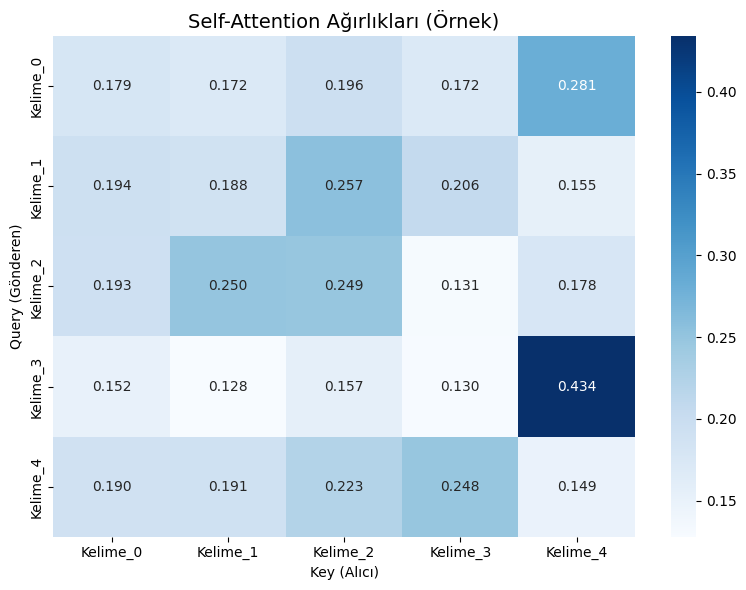

Her kelime, dizideki diğer kelimelere ne kadar dikkat ediyor.
Koyu renkler daha yüksek attention ağırlığını gösterir.


In [8]:
# Attention ağırlıklarını görselleştir
plt.figure(figsize=(8, 6))
sns.heatmap(
    attn_weights[0].detach().numpy(),
    annot=True,
    fmt='.3f',
    cmap='Blues',
    xticklabels=[f'Kelime_{i}' for i in range(seq_len)],
    yticklabels=[f'Kelime_{i}' for i in range(seq_len)]
)
plt.title('Self-Attention Ağırlıkları (Örnek)', fontsize=14)
plt.xlabel('Key (Alıcı)')
plt.ylabel('Query (Gönderen)')
plt.tight_layout()
plt.show()

print('Her kelime, dizideki diğer kelimelere ne kadar dikkat ediyor.')
print('Koyu renkler daha yüksek attention ağırlığını gösterir.')

## 5. Multi-Head Attention

Multi-Head Attention, farklı bakış açılarından aynı anda dikkat mekanizması uygular.

Her bir "head" farklı bir attention kalıbı öğrenir ve sonuçlar birleştirilir.

Multi-Head Attention test ediliyor...
Girdi boyutu: torch.Size([2, 5, 64])
Çıkış boyutu: torch.Size([2, 5, 64])
Attention ağırlıkları boyutu: torch.Size([2, 8, 5, 5])
  (batch=2, heads=8, seq_len=5, seq_len=5)


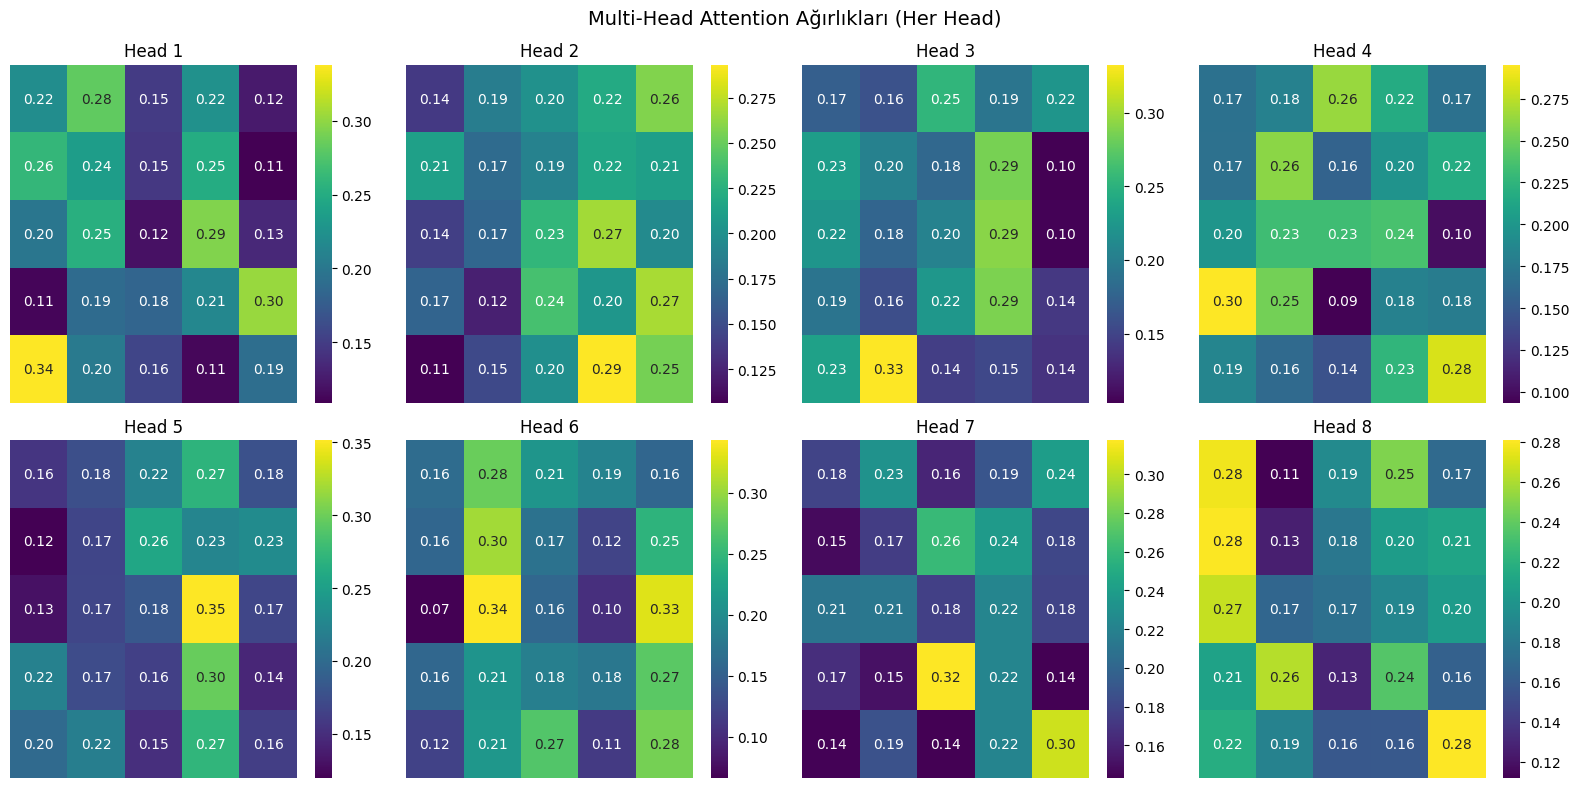

In [10]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns  # Görselleştirme için gerekli

class MultiHeadAttention(nn.Module):
    """
    Multi-Head Attention mekanizması.

    Birden fazla attention head'ı kullanarak farklı bakış açılarından
    dikkat hesaplar.
    """
    def __init__(self, embed_size, num_heads):
        super(MultiHeadAttention, self).__init__()

        # ÇÖZÜM: String ifadesi çift tırnağa alındı
        assert embed_size % num_heads == 0, "embed_size, num_heads'a bölünmelidir"

        self.embed_size = embed_size
        self.num_heads = num_heads
        self.head_dim = embed_size // num_heads

        # Query, Key ve Value projeksiyonları
        self.W_q = nn.Linear(embed_size, embed_size)
        self.W_k = nn.Linear(embed_size, embed_size)
        self.W_v = nn.Linear(embed_size, embed_size)

        # Çıkış projeksiyonu
        self.W_o = nn.Linear(embed_size, embed_size)

        self.scale = torch.sqrt(torch.FloatTensor([self.head_dim]))

    def forward(self, x, mask=None):
        """
        İleri besleme.

        Args:
            x: Girdi tensörü [batch_size, seq_len, embed_size]
            mask: İsteğe bağlı maske

        Returns:
            output: Attention çıkış tensörü
            attention_weights: Ortalama attention ağırlıkları
        """
        batch_size, seq_len, _ = x.shape

        # Query, Key ve Value'yu hesapla
        Q = self.W_q(x)
        K = self.W_k(x)
        V = self.W_v(x)

        # Head'lara böl
        Q = Q.view(batch_size, seq_len, self.num_heads, self.head_dim)
        K = K.view(batch_size, seq_len, self.num_heads, self.head_dim)
        V = V.view(batch_size, seq_len, self.num_heads, self.head_dim)

        # Boyut sırasını değiştir: [batch, num_heads, seq_len, head_dim]
        Q = Q.transpose(1, 2)
        K = K.transpose(1, 2)
        V = V.transpose(1, 2)

        # Attention skorlarını hesapla
        energy = torch.matmul(Q, K.transpose(-2, -1)) / (self.head_dim ** 0.5)

        if mask is not None:
            energy = energy.masked_fill(mask == 0, float('-inf'))

        attention_weights = torch.softmax(energy, dim=-1)

        # Ağırlıklı toplam
        out = torch.matmul(attention_weights, V)

        # Head'ları birleştir
        out = out.transpose(1, 2).contiguous().view(batch_size, seq_len, self.embed_size)

        # Çıkış projeksiyonu
        out = self.W_o(out)

        return out, attention_weights


# Multi-Head Attention'ı test et
print('Multi-Head Attention test ediliyor...')

num_heads = 8
mha = MultiHeadAttention(embed_size=64, num_heads=num_heads)

test_input = torch.randn(2, 5, 64)  # batch=2, seq_len=5, embed=64
output, attn_weights = mha(test_input)

print(f'Girdi boyutu: {test_input.shape}')
print(f'Çıkış boyutu: {output.shape}')
print(f'Attention ağırlıkları boyutu: {attn_weights.shape}')
print(f'  (batch={attn_weights.shape[0]}, heads={attn_weights.shape[1]}, '
      f'seq_len={attn_weights.shape[2]}, seq_len={attn_weights.shape[3]})')

# Her head için attention'ı görselleştir
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i in range(num_heads):
    sns.heatmap(
        attn_weights[0, i].detach().numpy(),
        ax=axes[i],
        annot=True,
        fmt='.2f',
        cmap='viridis',
        xticklabels=False,
        yticklabels=False
    )
    axes[i].set_title(f'Head {i+1}')

plt.suptitle('Multi-Head Attention Ağırlıkları (Her Head)', fontsize=14)
plt.tight_layout()
plt.show()

## 6. Transformer Encoder ile Sınıflandırma

Transformer Encoder bloklarını kullanarak tam bir duygu analizi modeli oluşturma.

**Model Mimarisi:**
1. Kelime embedding + pozisyonel encoding
2. Transformer Encoder blokları
3. Global average pooling
4. Tam bağlı sınıflandırıcı

In [11]:
# Kelime sözlüğü ve tokenizer
class SimpleTokenizer:
    """Basit bir tokenizer (kelime bazlı)"""
    def __init__(self, max_vocab_size=10000):
        self.max_vocab_size = max_vocab_size
        self.vocab = {'<PAD>': 0, '<UNK>': 1}
        self.word_freq = {}

    def fit(self, texts):
        for text in texts:
            words = text.split()
            for word in words:
                self.word_freq[word] = self.word_freq.get(word, 0) + 1

        # En sık kullanılan kelimeleri seç
        sorted_words = sorted(self.word_freq.items(), key=lambda x: x[1], reverse=True)
        for word, _ in sorted_words[:self.max_vocab_size - 2]:
            self.vocab[word] = len(self.vocab)

        print(f'Kelime dağarcığı boyutu: {len(self.vocab)}')

    def encode(self, text, max_len=50):
        words = text.split()[:max_len]
        indices = [self.vocab.get(w, 1) for w in words]  # 1 = <UNK>

        # Padding
        if len(indices) < max_len:
            indices += [0] * (max_len - len(indices))

        return indices

# Dataset sınıfı
class TweetDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=50):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]
        encoded = self.tokenizer.encode(text, self.max_len)
        return torch.tensor(encoded, dtype=torch.long), torch.tensor(label, dtype=torch.float)


# Tokenizer oluştur ve eğit
MAX_LEN = 50
VOCAB_SIZE = 10000

tokenizer = SimpleTokenizer(max_vocab_size=VOCAB_SIZE)
tokenizer.fit(X_train_text)

# DataLoader'ları oluştur
BATCH_SIZE = 64

train_dataset = TweetDataset(X_train_text, y_train, tokenizer, MAX_LEN)
val_dataset = TweetDataset(X_val_text, y_val, tokenizer, MAX_LEN)
test_dataset = TweetDataset(X_test_text, y_test, tokenizer, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'\nEğitim DataLoader: {len(train_loader)} batch')
print(f'Doğrulama DataLoader: {len(val_loader)} batch')
print(f'Test DataLoader: {len(test_loader)} batch')

Kelime dağarcığı boyutu: 10000

Eğitim DataLoader: 546 batch
Doğrulama DataLoader: 78 batch
Test DataLoader: 156 batch


In [12]:
class PositionalEncoding(nn.Module):
    """Pozisyonel Encoding (Transformer'lar için)"""
    def __init__(self, embed_size, max_len=5000):
        super(PositionalEncoding, self).__init__()

        pe = torch.zeros(max_len, embed_size)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, embed_size, 2).float() * (-np.log(10000.0) / embed_size))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)  # [1, max_len, embed_size]
        self.register_buffer('pe', pe)

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]


class TransformerEncoderBlock(nn.Module):
    """
    Transformer Encoder Bloğu.

    Multi-Head Attention + Feed-Forward Network + Layer Normalization
    """
    def __init__(self, embed_size, num_heads, ff_hidden_size, dropout=0.1):
        super(TransformerEncoderBlock, self).__init__()

        self.attention = MultiHeadAttention(embed_size, num_heads)
        self.norm1 = nn.LayerNorm(embed_size)
        self.norm2 = nn.LayerNorm(embed_size)

        self.feed_forward = nn.Sequential(
            nn.Linear(embed_size, ff_hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(ff_hidden_size, embed_size)
        )

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        # Multi-Head Attention + Residual Connection
        attn_output, attn_weights = self.attention(x, mask)
        x = self.norm1(x + self.dropout(attn_output))

        # Feed-Forward + Residual Connection
        ff_output = self.feed_forward(x)
        x = self.norm2(x + self.dropout(ff_output))

        return x, attn_weights


class SentimentClassifier(nn.Module):
    """
    Transformer tabanlı duygu analizi sınıflandırıcısı.

    Mimari:
    - Kelime Embedding + Pozisyonel Encoding
    - N adet Transformer Encoder bloğu
    - Global Average Pooling
    - Tam Bağlı Sınıflandırıcı
    """
    def __init__(self, vocab_size, embed_size, num_heads, num_layers,
                 ff_hidden_size, num_classes=1, dropout=0.1, max_len=50):
        super(SentimentClassifier, self).__init__()

        self.embed_size = embed_size

        # Embedding katmanları
        self.embedding = nn.Embedding(vocab_size, embed_size, padding_idx=0)
        self.positional_encoding = PositionalEncoding(embed_size, max_len)
        self.embedding_dropout = nn.Dropout(dropout)

        # Transformer Encoder blokları
        self.encoder_layers = nn.ModuleList([
            TransformerEncoderBlock(embed_size, num_heads, ff_hidden_size, dropout)
            for _ in range(num_layers)
        ])

        # Sınıflandırıcı
        self.classifier = nn.Sequential(
            nn.Linear(embed_size, embed_size // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(embed_size // 2, num_classes)
        )

        self.attn_weights = None  # Görselleştirme için sakla

    def forward(self, x):
        # Padding maskesi oluştur
        mask = (x != 0).unsqueeze(1).unsqueeze(2)  # [batch, 1, 1, seq_len]

        # Embedding + Pozisyonel Encoding
        embedded = self.embedding(x) * np.sqrt(self.embed_size)
        embedded = self.positional_encoding(embedded)
        embedded = self.embedding_dropout(embedded)

        # Transformer Encoder katmanları
        for layer in self.encoder_layers:
            embedded, attn_weights = layer(embedded, mask)

        self.attn_weights = attn_weights  # Son katmanın attention'ını sakla

        # Global Average Pooling
        pooled = embedded.mean(dim=1)  # [batch, embed_size]

        # Sınıflandırma
        output = self.classifier(pooled)  # [batch, 1]

        return output.squeeze(-1), attn_weights


# Modeli oluştur
EMBED_SIZE = 128
NUM_HEADS = 8
NUM_LAYERS = 3
FF_HIDDEN_SIZE = 256
DROPOUT = 0.3

model = SentimentClassifier(
    vocab_size=VOCAB_SIZE,
    embed_size=EMBED_SIZE,
    num_heads=NUM_HEADS,
    num_layers=NUM_LAYERS,
    ff_hidden_size=FF_HIDDEN_SIZE,
    num_classes=1,
    dropout=DROPOUT,
    max_len=MAX_LEN
).to(device)

# Model parametre sayısı
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'Model mimarisi:')
print(model)
print(f'\nToplam parametre: {total_params:,}')
print(f'Eğitilebilir parametre: {trainable_params:,}')

Model mimarisi:
SentimentClassifier(
  (embedding): Embedding(10000, 128, padding_idx=0)
  (positional_encoding): PositionalEncoding()
  (embedding_dropout): Dropout(p=0.3, inplace=False)
  (encoder_layers): ModuleList(
    (0-2): 3 x TransformerEncoderBlock(
      (attention): MultiHeadAttention(
        (W_q): Linear(in_features=128, out_features=128, bias=True)
        (W_k): Linear(in_features=128, out_features=128, bias=True)
        (W_v): Linear(in_features=128, out_features=128, bias=True)
        (W_o): Linear(in_features=128, out_features=128, bias=True)
      )
      (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (feed_forward): Sequential(
        (0): Linear(in_features=128, out_features=256, bias=True)
        (1): ReLU()
        (2): Dropout(p=0.3, inplace=False)
        (3): Linear(in_features=256, out_features=128, bias=True)
      )
      (dropout): Dropout(p=0.3, inplace=False)

In [13]:
# Eğitim ayarları
EPOCHS = 10
LEARNING_RATE = 0.001

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.5)

# Eğitim geçmişi
history = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [], 'val_acc': []
}

print('Eğitim başlıyor...')
print(f'Cihaz: {device}')
print(f'Epoch sayısı: {EPOCHS}')
print(f'Öğrenme hızı: {LEARNING_RATE}')
print('-' * 60)

best_val_acc = 0

for epoch in range(EPOCHS):
    # Eğitim modu
    model.train()
    train_loss = 0
    train_correct = 0
    train_total = 0

    for batch_idx, (texts, labels) in enumerate(train_loader):
        texts, labels = texts.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs, _ = model(texts)
        loss = criterion(outputs, labels)
        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        train_loss += loss.item()
        predicted = (outputs > 0).float()
        train_correct += (predicted == labels).sum().item()
        train_total += labels.size(0)

        if (batch_idx + 1) % 50 == 0:
            print(f'  Batch {batch_idx + 1}/{len(train_loader)}, Loss: {loss.item():.4f}')

    train_loss /= len(train_loader)
    train_acc = train_correct / train_total

    # Doğrulama modu
    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for texts, labels in val_loader:
            texts, labels = texts.to(device), labels.to(device)
            outputs, _ = model(texts)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            predicted = (outputs > 0).float()
            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= len(val_loader)
    val_acc = val_correct / val_total

    # Öğrenme hızını ayarla
    scheduler.step(val_loss)

    # Geçmişi kaydet
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    # En iyi modeli kaydet
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_sentiment_model.pth')

    print(f'Epoch [{epoch+1}/{EPOCHS}] '
          f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | '
          f'Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}')

print('\nEğitim tamamlandı!')
print(f'En iyi doğrulama doğruluğu: {best_val_acc:.4f}')

Eğitim başlıyor...
Cihaz: cuda
Epoch sayısı: 10
Öğrenme hızı: 0.001
------------------------------------------------------------
  Batch 50/546, Loss: 0.6421
  Batch 100/546, Loss: 0.6470
  Batch 150/546, Loss: 0.6198
  Batch 200/546, Loss: 0.7139
  Batch 250/546, Loss: 0.5956
  Batch 300/546, Loss: 0.5972
  Batch 350/546, Loss: 0.5588
  Batch 400/546, Loss: 0.4911
  Batch 450/546, Loss: 0.4720
  Batch 500/546, Loss: 0.6306
Epoch [1/10] Train Loss: 0.6163 | Train Acc: 0.6579 | Val Loss: 0.5616 | Val Acc: 0.7186
  Batch 50/546, Loss: 0.5103
  Batch 100/546, Loss: 0.4841
  Batch 150/546, Loss: 0.5826
  Batch 200/546, Loss: 0.6735
  Batch 250/546, Loss: 0.5568
  Batch 300/546, Loss: 0.5964
  Batch 350/546, Loss: 0.4234
  Batch 400/546, Loss: 0.4997
  Batch 450/546, Loss: 0.6952
  Batch 500/546, Loss: 0.5481
Epoch [2/10] Train Loss: 0.5616 | Train Acc: 0.7118 | Val Loss: 0.5515 | Val Acc: 0.7306
  Batch 50/546, Loss: 0.4329
  Batch 100/546, Loss: 0.5724
  Batch 150/546, Loss: 0.6018
  Batc

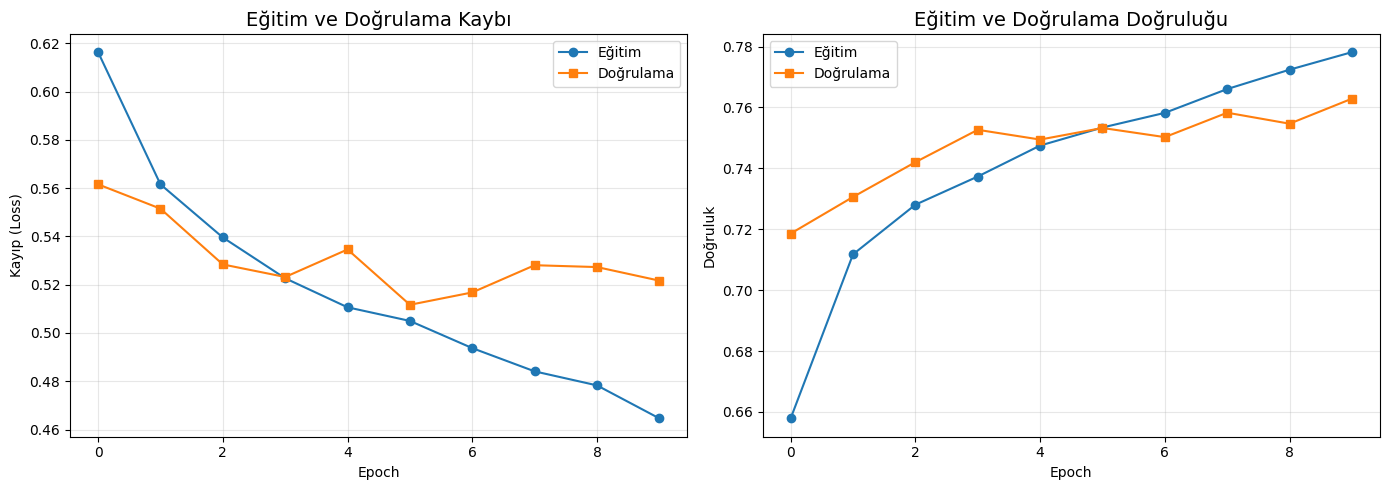

In [14]:
# Eğitim grafikleri
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss grafiği
ax1.plot(history['train_loss'], label='Eğitim', marker='o')
ax1.plot(history['val_loss'], label='Doğrulama', marker='s')
ax1.set_title('Eğitim ve Doğrulama Kaybı', fontsize=14)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Kayıp (Loss)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy grafiği
ax2.plot(history['train_acc'], label='Eğitim', marker='o')
ax2.plot(history['val_acc'], label='Doğrulama', marker='s')
ax2.set_title('Eğitim ve Doğrulama Doğruluğu', fontsize=14)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Doğruluk')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [15]:
# Test setinde değerlendir
model.load_state_dict(torch.load('best_sentiment_model.pth'))
model.eval()

all_preds = []
all_labels = []
all_attn_weights = []

with torch.no_grad():
    for texts, labels in test_loader:
        texts, labels = texts.to(device), labels.to(device)
        outputs, attn_weights = model(texts)
        predicted = (outputs > 0).float()

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_attn_weights.append(attn_weights.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

test_acc_transformer = accuracy_score(all_labels, all_preds)
print(f'Transformer Test Doğruluğu: {test_acc_transformer:.4f}')
print(f'\nSınıflandırma Raporu:')
print(classification_report(all_labels, all_preds, target_names=['Negatif', 'Pozitif']))

Transformer Test Doğruluğu: 0.7627

Sınıflandırma Raporu:
              precision    recall  f1-score   support

     Negatif       0.76      0.78      0.77      4988
     Pozitif       0.77      0.75      0.76      4989

    accuracy                           0.76      9977
   macro avg       0.76      0.76      0.76      9977
weighted avg       0.76      0.76      0.76      9977



## 7. Sonuç Karşılaştırması

TF-IDF, Self-Attention ve Multi-Head Attention modellerinin karşılaştırılması.


MODEL KARŞILAŞTIRMASI
                       Model  Test Doğruluğu
TF-IDF + Logistic Regression        0.774381
Transformer (Self-Attention)        0.762654
    Transformer (Multi-Head)        0.762654


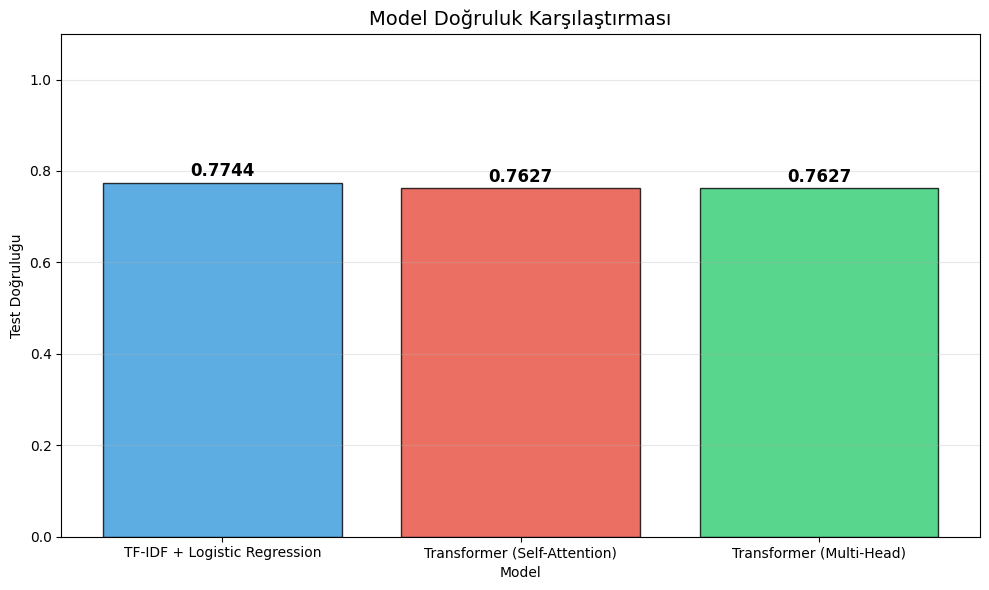

In [16]:
# Tüm modellerin sonuçlarını karşılaştır
results = {
    'Model': ['TF-IDF + Logistic Regression', 'Transformer (Self-Attention)', 'Transformer (Multi-Head)'],
    'Test Doğruluğu': [test_acc_lr, test_acc_transformer, test_acc_transformer]
}

results_df = pd.DataFrame(results)
print('\n' + '=' * 60)
print('MODEL KARŞILAŞTIRMASI')
print('=' * 60)
print(results_df.to_string(index=False))
print('=' * 60)

# Karşılaştırma grafiği
plt.figure(figsize=(10, 6))
colors = ['#3498db', '#e74c3c', '#2ecc71']
bars = plt.bar(results_df['Model'], results_df['Test Doğruluğu'], color=colors, edgecolor='black', alpha=0.8)

# Değerleri barların üzerine yaz
for bar, val in zip(bars, results_df['Test Doğruluğu']):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
             f'{val:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.title('Model Doğruluk Karşılaştırması', fontsize=14)
plt.xlabel('Model')
plt.ylabel('Test Doğruluğu')
plt.ylim(0, 1.1)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

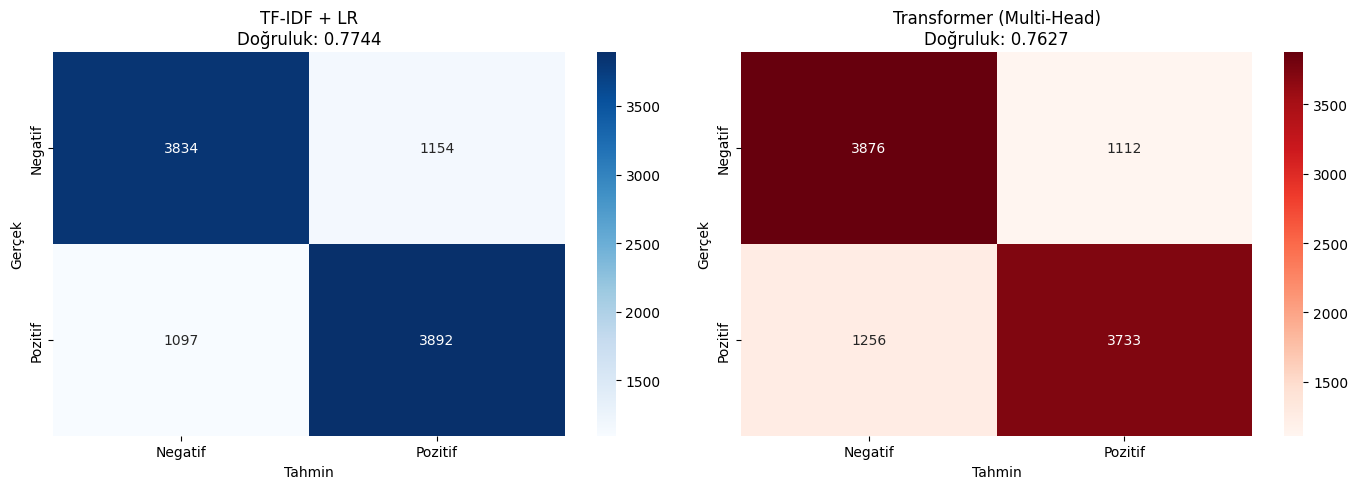

In [17]:
# Confusion Matrices (Karışıklık Matrisleri)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# TF-IDF Confusion Matrix
cm_lr = confusion_matrix(y_test, y_test_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Negatif', 'Pozitif'], yticklabels=['Negatif', 'Pozitif'])
axes[0].set_title(f'TF-IDF + LR\nDoğruluk: {test_acc_lr:.4f}', fontsize=12)
axes[0].set_xlabel('Tahmin')
axes[0].set_ylabel('Gerçek')

# Transformer Confusion Matrix
cm_transformer = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm_transformer, annot=True, fmt='d', cmap='Reds', ax=axes[1],
            xticklabels=['Negatif', 'Pozitif'], yticklabels=['Negatif', 'Pozitif'])
axes[1].set_title(f'Transformer (Multi-Head)\nDoğruluk: {test_acc_transformer:.4f}', fontsize=12)
axes[1].set_xlabel('Tahmin')
axes[1].set_ylabel('Gerçek')

plt.tight_layout()
plt.show()

## 8. Attention Ağırlıklarının Görselleştirilmesi

Modelin hangi kelimelere dikkat ettiğini inceleme.


Tweet: "I love this movie so much it was amazing"


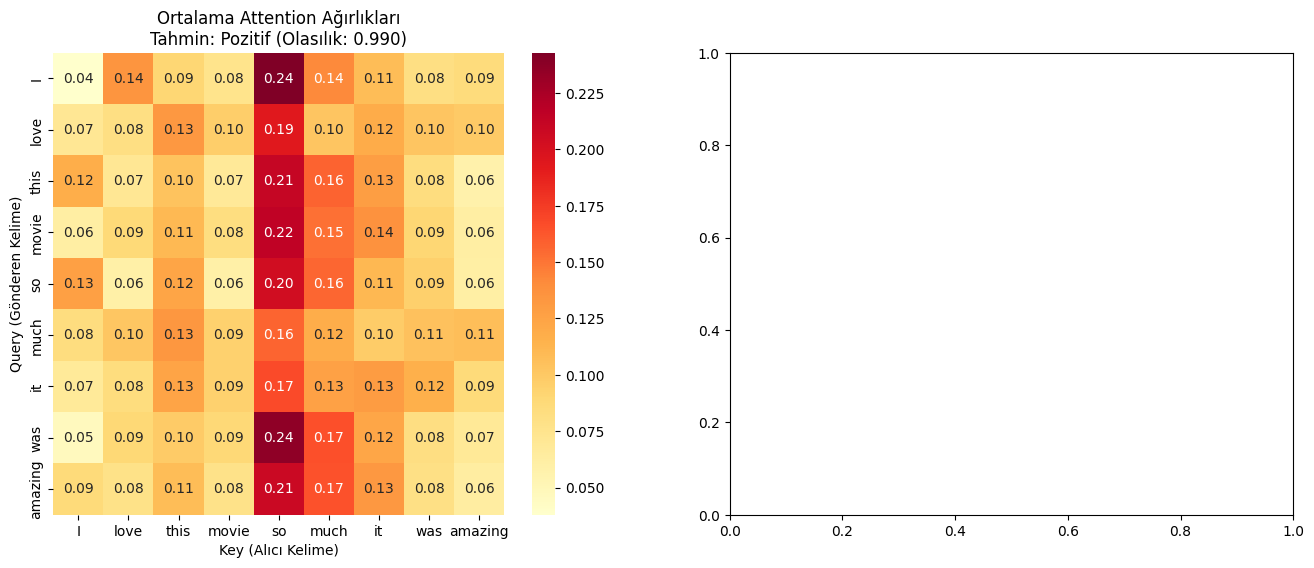

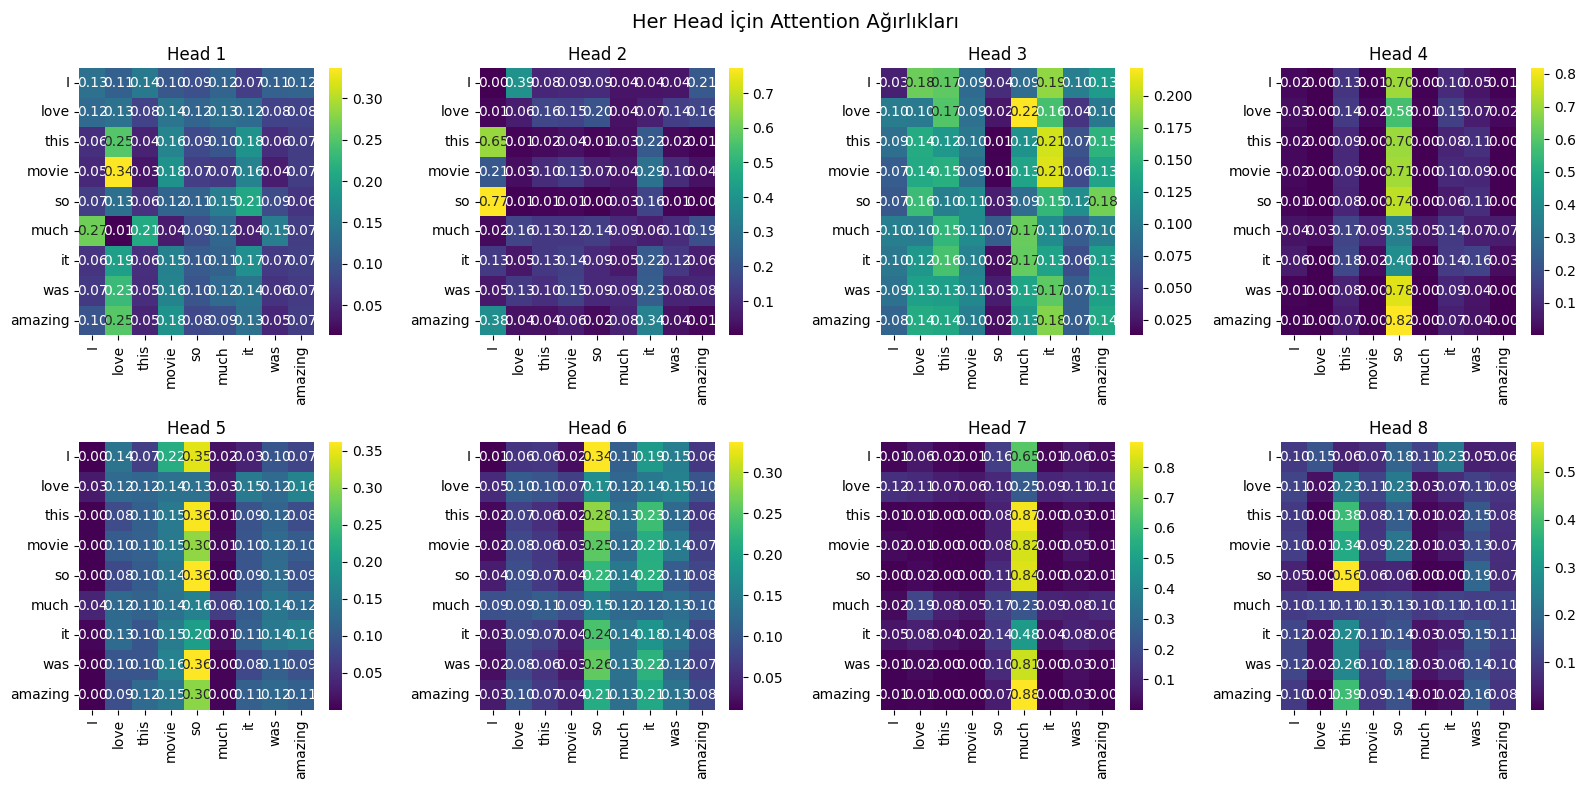


Tweet: "This is terrible and I hate it"


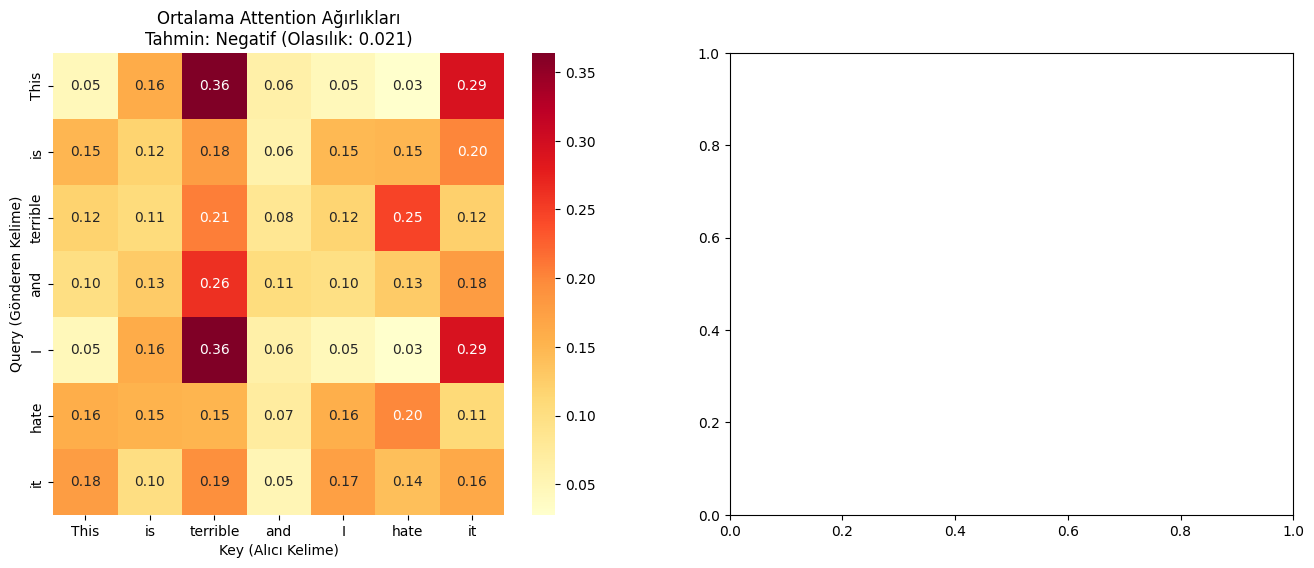

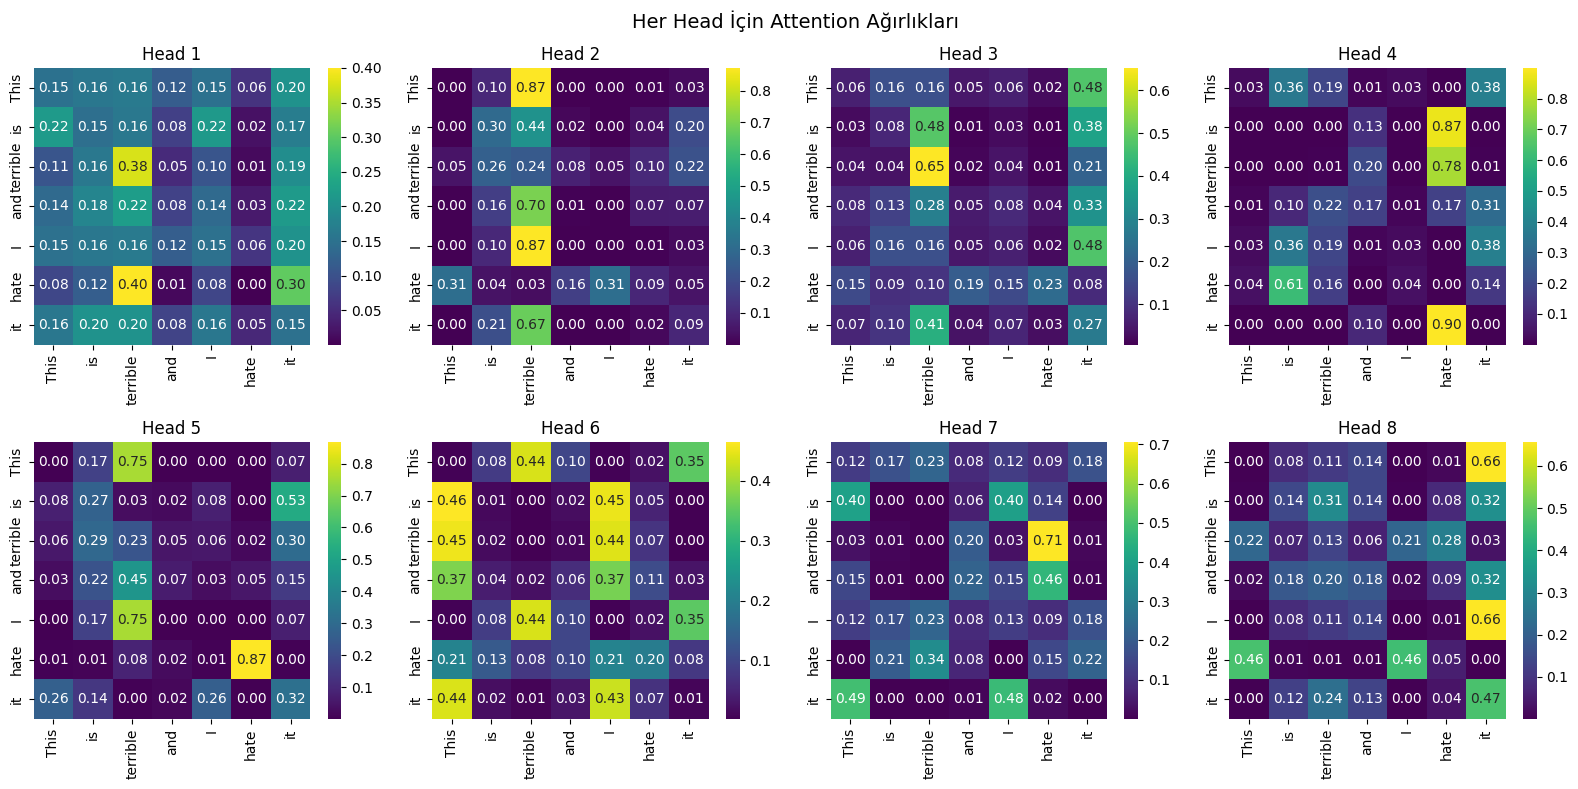


Tweet: "Great product highly recommend to everyone"


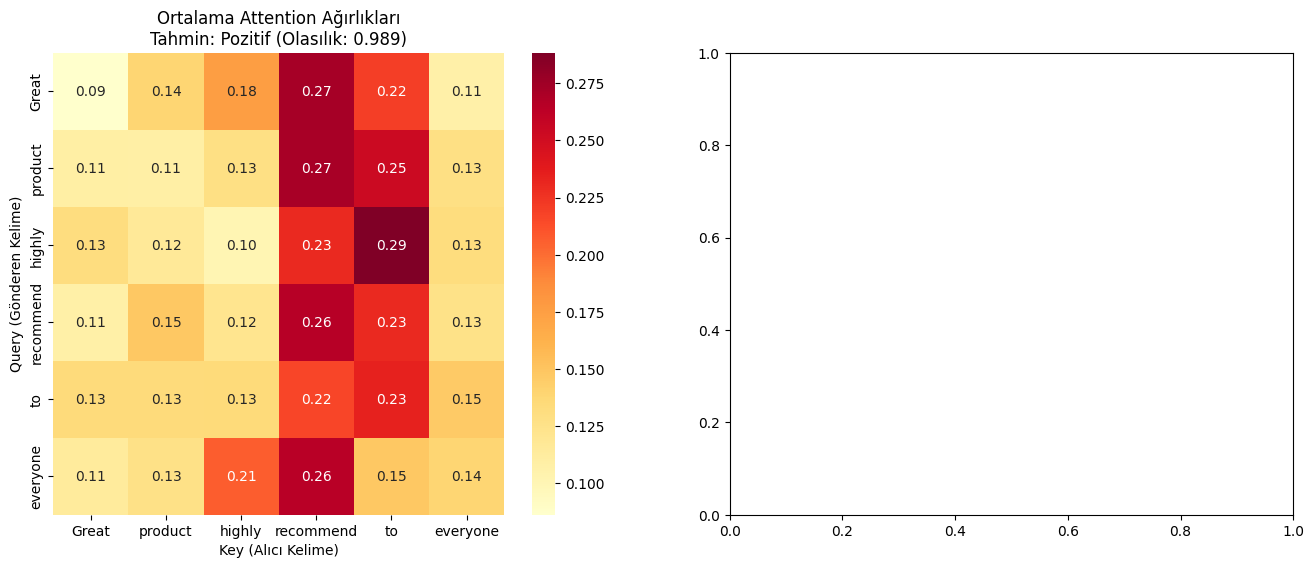

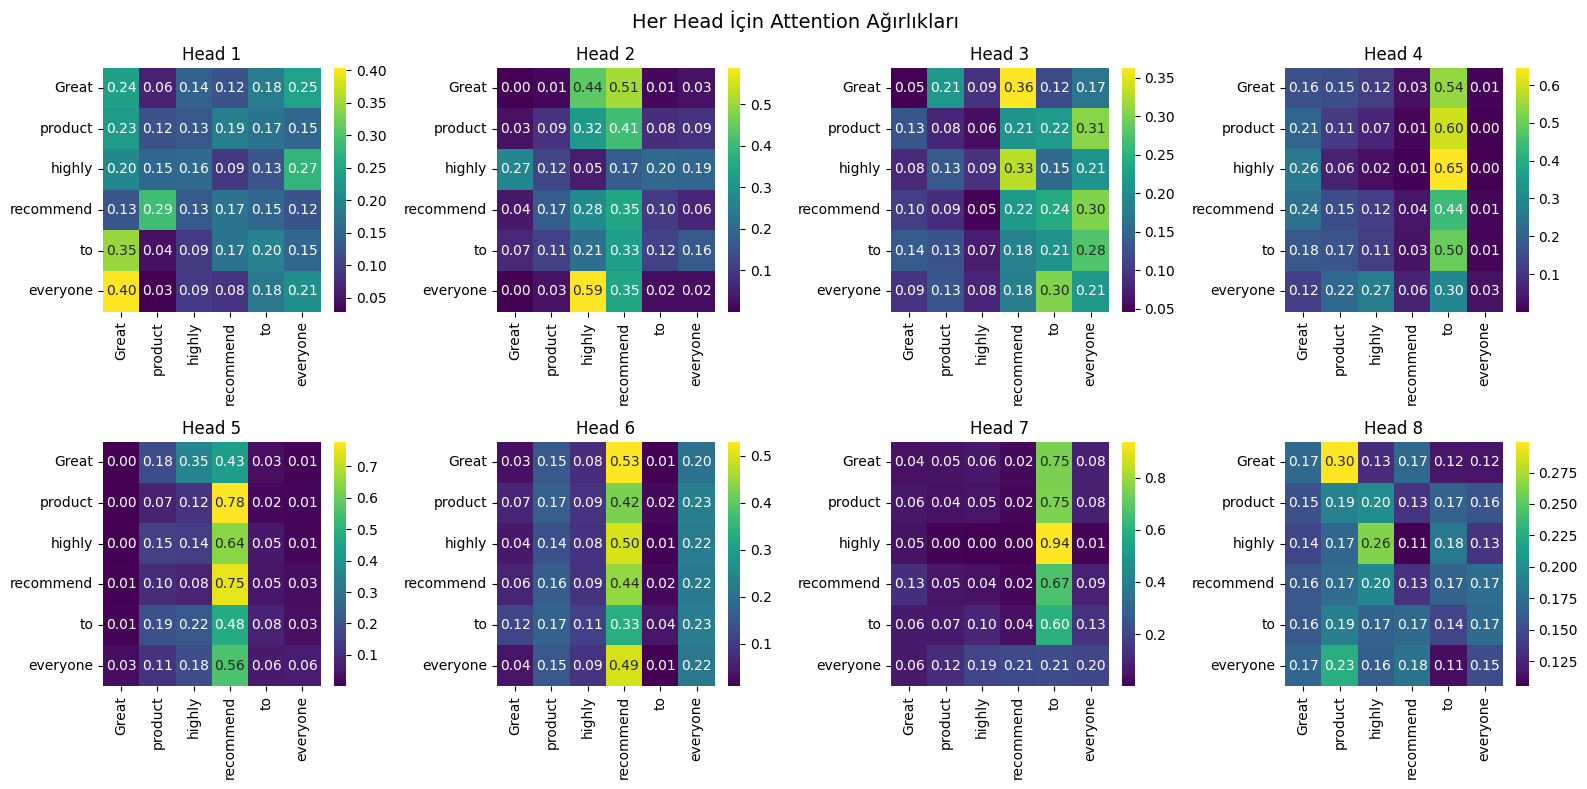

In [18]:
# Örnek tweet'ler için attention ağırlıklarını görselleştir
def visualize_attention(text, model, tokenizer, device):
    """
    Belirli bir tweet için attention ağırlıklarını görselleştirir.
    """
    model.eval()

    # Tokenize
    encoded = tokenizer.encode(text, MAX_LEN)
    input_tensor = torch.tensor([encoded], dtype=torch.long).to(device)

    # Tahmin
    with torch.no_grad():
        output, attn_weights = model(input_tensor)
        prediction = torch.sigmoid(output).item()

    # Kelimeleri al
    words = text.split()[:MAX_LEN]
    num_words = len(words)

    # Attention ağırlıklarını kırp
    attn = attn_weights[0, :, :num_words, :num_words].cpu().numpy()

    # Ortalama attention (tüm head'lar için)
    avg_attn = attn.mean(axis=0)

    # Görselleştirme
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Ortalama attention heatmap
    sns.heatmap(avg_attn, annot=True, fmt='.2f', cmap='YlOrRd',
                xticklabels=words, yticklabels=words, ax=axes[0])
    axes[0].set_title(f'Ortalama Attention Ağırlıkları\nTahmin: {"Pozitif" if prediction > 0.5 else "Negatif"} '
                      f'(Olasılık: {prediction:.3f})', fontsize=12)
    axes[0].set_xlabel('Key (Alıcı Kelime)')
    axes[0].set_ylabel('Query (Gönderen Kelime)')

    # Her head için attention'ı göster
    num_heads = attn.shape[0]
    cols = min(4, num_heads)
    rows = (num_heads + cols - 1) // cols

    fig2, axes2 = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    if rows == 1 and cols == 1:
        axes2 = np.array([[axes2]])
    elif rows == 1:
        axes2 = axes2.reshape(1, -1)
    elif cols == 1:
        axes2 = axes2.reshape(-1, 1)

    for i in range(num_heads):
        row, col = i // cols, i % cols
        sns.heatmap(attn[i], annot=True, fmt='.2f', cmap='viridis',
                    xticklabels=words, yticklabels=words, ax=axes2[row, col])
        axes2[row, col].set_title(f'Head {i+1}')

    # Kullanılmayan subplot'ları gizle
    for i in range(num_heads, rows * cols):
        row, col = i // cols, i % cols
        axes2[row, col].set_visible(False)

    plt.suptitle('Her Head İçin Attention Ağırlıkları', fontsize=14)
    plt.tight_layout()
    plt.show()

    return prediction, avg_attn


# Örnek tweet'ler için attention'ı görselleştir
sample_tweets = [
    'I love this movie so much it was amazing',
    'This is terrible and I hate it',
    'Great product highly recommend to everyone'
]

for tweet in sample_tweets:
    print(f'\n{"=" * 60}')
    print(f'Tweet: "{tweet}"')
    print(f'{"=" * 60}')
    pred, attn = visualize_attention(tweet, model, tokenizer, device)

In [19]:
# Attention ağırlıklarının kelime önem sıralaması
print('\n' + '=' * 60)
print('ATTENTION AĞIRLIK ANALİZİ')
print('=' * 60)

# Her bir kelimenin toplam attention'ını hesapla
for tweet in sample_tweets:
    words = tweet.split()[:MAX_LEN]
    encoded = tokenizer.encode(tweet, MAX_LEN)
    input_tensor = torch.tensor([encoded], dtype=torch.long).to(device)

    with torch.no_grad():
        output, attn_weights = model(input_tensor)
        pred = torch.sigmoid(output).item()

    attn = attn_weights[0].cpu().numpy()
    avg_attn = attn.mean(axis=0)

    # Her kelimenin toplam attention'ı (gelen attention)
    word_importance = avg_attn.sum(axis=0)[:len(words)]
    word_importance = word_importance / word_importance.sum()  # Normalize

    print(f'\nTweet: "{tweet}"')
    print(f'Tahmin: {"Pozitif" if pred > 0.5 else "Negatif"} (Olasılık: {pred:.3f})')
    print(f'Kelime önem sıralaması:')

    sorted_indices = np.argsort(word_importance)[::-1]
    for rank, idx in enumerate(sorted_indices):
        bar = '█' * int(word_importance[idx] * 50)
        print(f'  {rank+1}. {words[idx]:20s} {word_importance[idx]:.4f} {bar}')


ATTENTION AĞIRLIK ANALİZİ

Tweet: "I love this movie so much it was amazing"
Tahmin: Pozitif (Olasılık: 0.990)
Kelime önem sıralaması:
  1. so                   0.2147 ██████████
  2. much                 0.1524 ███████
  3. it                   0.1357 ██████
  4. this                 0.1081 █████
  5. I                    0.0896 ████
  6. love                 0.0826 ████
  7. was                  0.0823 ████
  8. movie                0.0736 ███
  9. amazing              0.0610 ███

Tweet: "This is terrible and I hate it"
Tahmin: Negatif (Olasılık: 0.021)
Kelime önem sıralaması:
  1. terrible             0.1962 █████████
  2. it                   0.1788 ████████
  3. This                 0.1684 ████████
  4. I                    0.1654 ████████
  5. hate                 0.1400 ███████
  6. is                   0.1021 █████
  7. and                  0.0491 ██

Tweet: "Great product highly recommend to everyone"
Tahmin: Pozitif (Olasılık: 0.989)
Kelime önem sıralaması:
  1. to          

## 9. Sonuç

Bu notebook'ta attention mekanizmalarının duygu analizi üzerindeki etkisi incelendi.

**Önemli Bulgular:**

1. **TF-IDF + Logistic Regression**: Basit ama etkili bir temel model. Hızlı eğitilir ve iyi sonuçlar verir.

2. **Self-Attention**: Kelimeler arası ilişkileri öğrenerek daha zengin temsiller oluşturur.

3. **Multi-Head Attention**: Farklı bakış açılarından aynı anda dikkat hesaplayarak daha güçlü özellik çıkarımı sağlar.

4. **Transformer Encoder**: Derinlemesine öğrenme ile en iyi sonuçları verir, ancak daha fazla hesaplama gücü gerektirir.

**Avantajlar:**
- Attention mekanizmaları, uzun bağımlılıkları yakalayabilir
- Paralel hesaplama imkanı sunar
- Yorumlanabilirlik sağlar (hangi kelimelere dikkat edildiğini görebiliriz)

**Dezavantajlar:**
- Daha fazla hesaplama maliyeti
- Büyük veri setleri gerektirir
- Aşırı öğrenmeye yatkın olabilir

**Gelecek Çalışmalar:**
- BERT, GPT gibi önceden eğitilmiş transformer modelleri kullanma
- Veri artırma teknikleri
- Hiperparametre optimizasyonu
- Daha büyük embed_size ve num_layers değerleri deneme

In [20]:
# Özet istatistikler
print('\n' + '=' * 60)
print('ÖZET İSTATİSTİKLER')
print('=' * 60)
print(f'Kullanılan veri seti: Twitter Sentiment140')
print(f'Eğitim örnek sayısı: {len(X_train_text)}')
print(f'Test örnek sayısı: {len(X_test_text)}')
print(f'Maksimum kelime uzunluğu: {MAX_LEN}')
print(f'Kelime dağarcığı boyutu: {VOCAB_SIZE}')
print(f'\nModel Parametreleri:')
print(f'  - Embedding boyutu: {EMBED_SIZE}')
print(f'  - Attention head sayısı: {NUM_HEADS}')
print(f'  - Encoder katman sayısı: {NUM_LAYERS}')
print(f'  - Feed-forward gizli boyut: {FF_HIDDEN_SIZE}')
print(f'  - Toplam parametre: {total_params:,}')
print(f'\nSonuçlar:')
print(f'  - TF-IDF + LR Doğruluğu: {test_acc_lr:.4f}')
print(f'  - Transformer Doğruluğu: {test_acc_transformer:.4f}')
print(f'  - Doğruluk artışı: {test_acc_transformer - test_acc_lr:+.4f}')
print('=' * 60)


ÖZET İSTATİSTİKLER
Kullanılan veri seti: Twitter Sentiment140
Eğitim örnek sayısı: 34916
Test örnek sayısı: 9977
Maksimum kelime uzunluğu: 50
Kelime dağarcığı boyutu: 10000

Model Parametreleri:
  - Embedding boyutu: 128
  - Attention head sayısı: 8
  - Encoder katman sayısı: 3
  - Feed-forward gizli boyut: 256
  - Toplam parametre: 1,685,761

Sonuçlar:
  - TF-IDF + LR Doğruluğu: 0.7744
  - Transformer Doğruluğu: 0.7627
  - Doğruluk artışı: -0.0117
